In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    select datetime
    from pageviews 
    where uid like 'user_%'
"""
data = pd.io.sql.read_sql(query, connect)

data['datetime'] = pd.to_datetime(data['datetime'])
data = data.groupby(data['datetime'].dt.date).count()
data = data.rename(columns={'datetime': 'count'})
data.index.name = 'date'
data.shape

(33, 1)

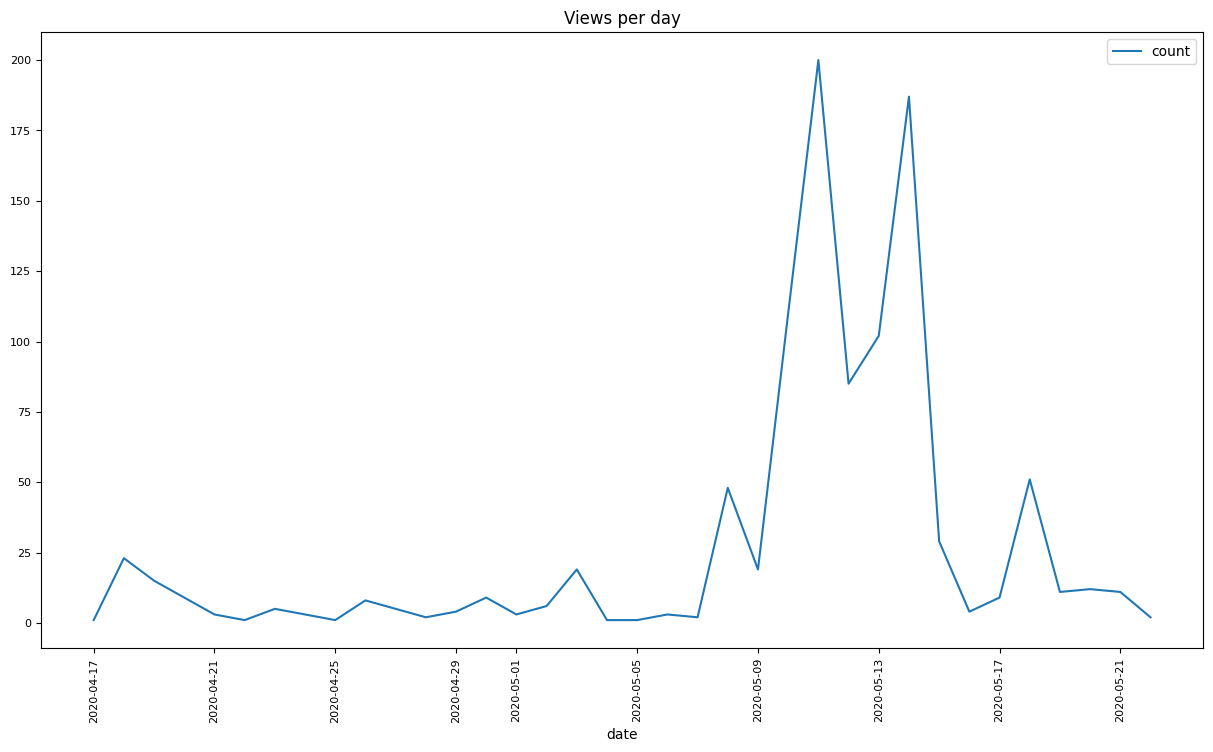

In [7]:
data.plot(fontsize=8, figsize=(15,8), title='Views per day', rot=90);

In [8]:
connect.close()